# **Linear Regression Assumptions**

### **Topic Roadmap**

**1. Imports and Dataset Loading**

**2. Train-Test Split & Baseline Model**

**3. Assumption 1: Linear Relationship**

**4. Assumption 2: Multicollinearity Check (VIF)**

**5. Assumption 3: Normality of Residuals**

**6. Assumption 4: Homoscedasticity**

**7. Assumption 5: Autocorrelation of Residuals**

**8. Key Revision Notes**

## **1. Imports and Dataset Loading**

Load standard visualization and modeling tools, then load the synthetic dataset designed to test our regression assumptions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('docs/Lecture-040-data.csv')
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


## **2. Train-Test Split & Baseline Model**

We need a fitted model to calculate residuals, which are required to test most of the linear regression assumptions.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Isolate features and target
X = df.iloc[:, 0:3].values
y = df.iloc[:, -1].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Calculate Residuals (Error = Actual - Predicted)
y_pred = model.predict(X_test)
residual = y_test - y_pred

## **3. Assumption 1: Linear Relationship**

The target variable must have a linear relationship with the independent variables. We can visually inspect this by plotting each feature against the target.

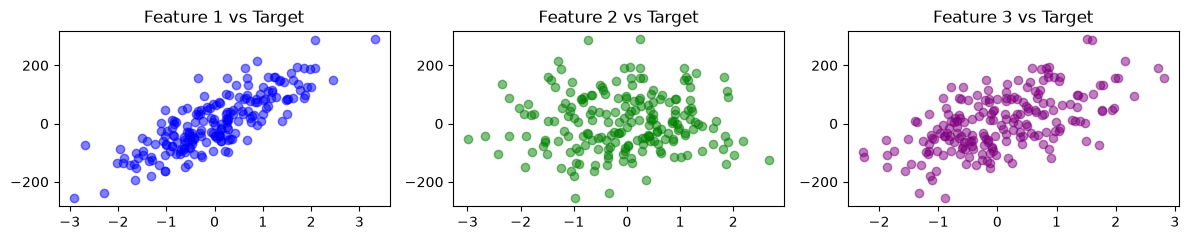

In [6]:
# Scatter plot for each feature vs target
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'], color='blue', alpha=0.5)
ax1.set_title("Feature 1 vs Target")

ax2.scatter(df['feature2'], df['target'], color='green', alpha=0.5)
ax2.set_title("Feature 2 vs Target")

ax3.scatter(df['feature3'], df['target'], color='purple', alpha=0.5)
ax3.set_title("Feature 3 vs Target")

plt.tight_layout()
plt.show()

Alternatively, we can compute the correlation matrix. Values close to 1 or -1 indicate a strong linear relationship.

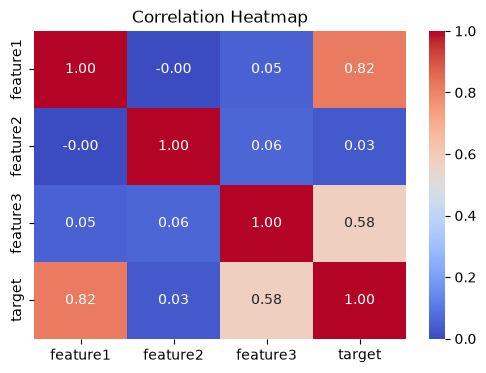

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## **4. Assumption 2: Multicollinearity Check (VIF)**

The independent variables should not be highly correlated with each other. We use the Variance Inflation Factor (VIF) to detect multicollinearity. Generally, a VIF > 5 indicates high multicollinearity.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

# Calculate VIF for each feature in X_train
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

# Display results
vif_df = pd.DataFrame({'VIF': vif}, index=df.columns[0:3]).T
display(vif_df)

,feature1,feature2,feature3
VIF,1.010326,1.009871,1.01395


## **5. Assumption 3: Normality of Residuals**

The residuals (errors) of the model should be normally distributed. We can check this using a Kernel Density Estimate (KDE) plot and a Quantile-Quantile (Q-Q) plot.

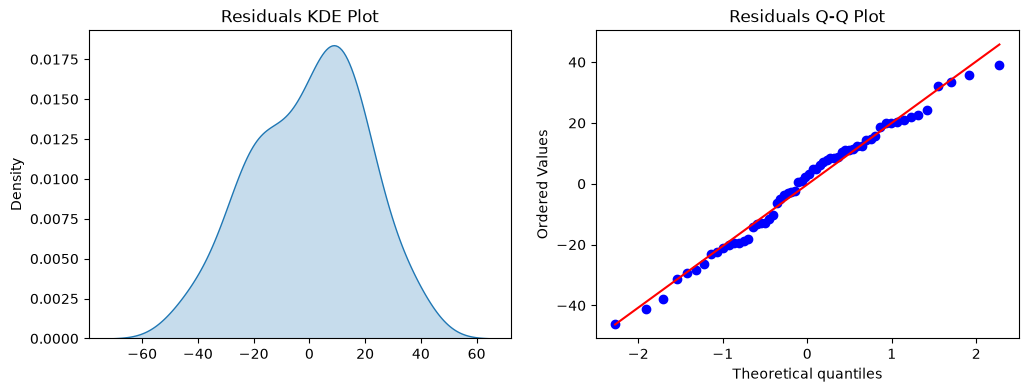

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

# KDE Plot
sns.kdeplot(residual, ax=ax1, fill=True)
ax1.set_title('Residuals KDE Plot')

# Q-Q Plot
sp.stats.probplot(residual, plot=ax2, fit=True)
ax2.set_title('Residuals Q-Q Plot')

plt.show()

## **6. Assumption 4: Homoscedasticity**

Homoscedasticity means the variance of the residuals should remain constant across all predicted values. A scatter plot of predicted values vs. residuals should show a random spread without any discernible pattern (like a cone or funnel shape).

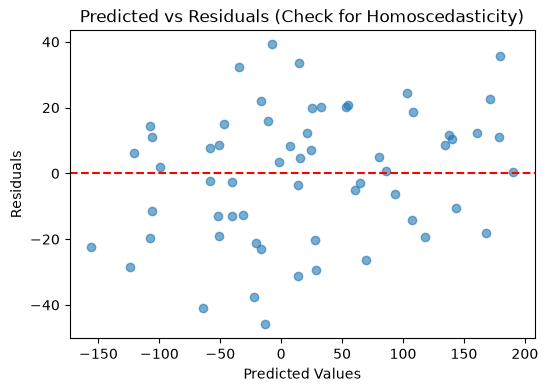

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residual, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Predicted vs Residuals (Check for Homoscedasticity)')
plt.show()

## **7. Assumption 5: Autocorrelation of Residuals**

Residuals should be independent of each other. Autocorrelation (patterns in the sequence of errors) is a common issue in time-series data. A simple line plot of residuals should look like random noise.

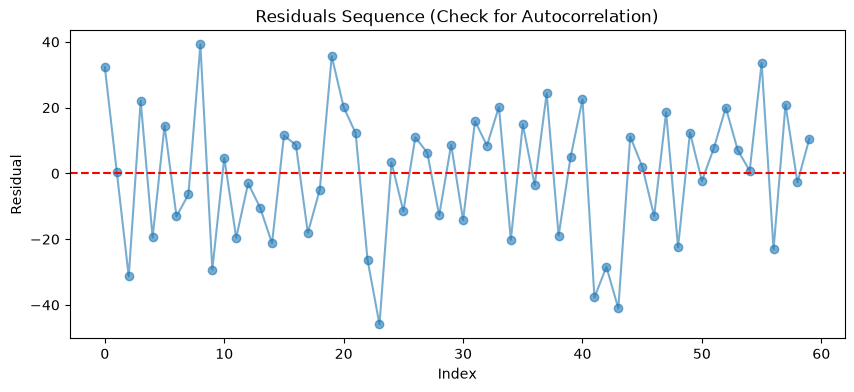

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(residual, marker='o', linestyle='-', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Sequence (Check for Autocorrelation)')
plt.xlabel('Index')
plt.ylabel('Residual')
plt.show()

## **8. Key Revision Notes**

If a dataset fails these assumptions, Linear Regression is likely the wrong model:
1. **Linearity:** The model assumes the data can be separated by a straight line/hyperplane. If the relationship is curved, try Polynomial Regression.
2. **No Multicollinearity:** Independent variables must not be heavily correlated with each other. If VIF > 5, consider dropping one of the correlated features or using Ridge/Lasso regularization to penalize weights.
3. **Normality of Residuals:** Errors should form a bell curve. If they don't, it indicates outliers or that the model is failing to capture a significant pattern. Try transforming the target variable (e.g., Log transform).
4. **Homoscedasticity:** Constant error variance. If a funnel shape appears in the residual plot (Heteroscedasticity), it means the model struggles to predict larger/smaller values consistently.
5. **No Autocorrelation:** Errors should not follow a time-based pattern. If they do, standard linear regression is invalid; use time-series models like ARIMA instead.